In [1]:
#Importo as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carrego os arquivos de dados
dfVendas = pd.read_csv("dfVendas.csv", delimiter= ",")
dfVendasExtras = pd.read_csv("dfVendasExtras.csv", delimiter= ",")
dfProdutos = pd.read_csv("produtos.csv", delimiter= ",")

In [3]:
#Concateno os arquivos de Vendas
dfVendasTotal = pd.concat([dfVendas, dfVendasExtras], ignore_index=True)
dfVendasTotal

,ID_Venda,ID_Cliente,ID_Produto,Data,Quantidade,Canal,Valor_Total,ID_Campanha
0,1,350,45,2022-09-23,4,Online,5795.64,17
1,2,925,68,2024-02-09,1,Loja Física,4614.41,16
2,3,915,75,2022-09-11,4,Online,2057.48,17
3,4,494,47,2024-05-10,4,Loja Física,12864.44,9
4,5,523,79,2023-10-15,4,Loja Física,13317.28,5
...,...,...,...,...,...,...,...,...
23995,23996,99,68,2024-11-06,2,Online,9228.82,10
23996,23997,225,90,2024-10-14,2,Loja Física,6536.63,20
23997,23998,974,15,2024-12-29,4,Loja Física,12565.21,6
23998,23999,269,44,2025-06-13,3,Loja Física,9834.99,15


In [4]:
#Realizo o merge entre os dataFrames
dfVendasProdutos = pd.merge(dfVendasTotal, dfProdutos, left_on="ID_Produto", right_on="ID_Produto", how="inner")
dfVendasProdutos.head(2)

,ID_Venda,ID_Cliente,ID_Produto,Data,Quantidade,Canal,Valor_Total,ID_Campanha,Nome_Produto,Categoria,Preco,Marca
0,1,350,45,2022-09-23,4,Online,5795.64,17,Fritadeira Airfryer Mondial,Móveis,1448.91,Mondial
1,2,925,68,2024-02-09,1,Loja Física,4614.41,16,Monitor LG Ultrawide,Eletrodomésticos,4614.41,LG


In [5]:
#Soma os valores de venda (Valor_Total) por produto (Nome_Produto)
dfValorTotalProduto = dfVendasProdutos.groupby("Nome_Produto")["Valor_Total"].sum().reset_index()
dfValorTotalProduto

,Nome_Produto,Valor_Total
0,Adaptador HDMI,655377.30
1,Ar-condicionado LG Dual Inverter,530204.60
2,Ar-condicionado Split 12000 BTUs,2074886.48
3,Aspirador de Pó Electrolux,3187353.20
4,Aspirador de Pó Mondial,2788195.80
...,...,...
94,Tripé para Câmera,2345800.66
95,Ventilador Arno,1833664.34
96,Ventilador Mondial,2482417.85
97,Volante Logitech G29,1667260.80


In [6]:
#Cria o array com os dados do total de vendas por produto
arrayValorTotalProduto = np.array(dfValorTotalProduto["Valor_Total"])
arrayValorTotalProduto

array([ 655377.3 ,  530204.6 , 2074886.48, 3187353.2 , 2788195.8 ,
       2305111.95, 2059830.03,  540777.54, 1090375.76, 1412490.52,
        242220.81, 1071170.65, 1580532.32,  306837.54, 2755890.92,
       2350103.9 , 2695892.2 , 2549378.08, 2012520.11, 1161106.39,
       2516554.56, 3380413.2 ,  199653.3 ,  164965.88, 2114646.55,
        197633.66, 2138720.91, 2601251.81, 1708886.88, 2552024.95,
        821457.49, 1708583.85, 2808625.61,  869346.  , 1179008.56,
       2582107.42, 2791998.6 , 1812196.79, 1274073.12, 2381449.77,
        624997.34, 2363795.6 ,  171163.19, 1629072.77, 3076768.62,
        112603.61, 3301043.14, 1936653.28, 2137471.16, 3372299.62,
       2157994.26, 1961943.37, 2575868.02, 3119764.51, 2750188.36,
       1908969.14, 1646696.16, 2871178.14, 2584832.29, 2049289.18,
       3112916.84,  704799.73,  991366.68, 2050861.12,  793810.63,
        532473.45, 2055017.91, 2536796.88, 1559252.64, 2614609.04,
       2121916.89,  727095.72, 2136966.09, 1135805.99, 2316179

In [7]:
#Cálculos estatísticos
media = np.mean(arrayValorTotalProduto)
mediana = np.median(arrayValorTotalProduto)
q1 = np.percentile(arrayValorTotalProduto, 25)
q2 = np.percentile(arrayValorTotalProduto, 50)
q3 = np.percentile(arrayValorTotalProduto, 75)
distancia = (media - mediana) / mediana
iqr = q3 - q1
limSuperior = q3 + (1.5 * iqr)
limInferior = q1 - (1.5 * iqr)
variancia = np.var(arrayValorTotalProduto)
desvio_padrao = np.std(arrayValorTotalProduto)
coeficiente_variacao = (desvio_padrao / media) * 100
distancia_variancia = (variancia / (media ** 2)) * 100
minimo = np.min(arrayValorTotalProduto)
maximo = np.max(arrayValorTotalProduto)
amplitude = maximo - minimo

print(f'Média     = {media:,.2f}')
print(f'Mediana   = {mediana:,.2f}')
print(f'Q1        = {q1:,.2f}')
print(f'Q2        = {q2:,.2f}')
print(f'Q3        = {q3:,.2f}')
print(f'Distância = {distancia * 100:.2f} %')
print(f'Lim. Sup. = {limSuperior:,.2f}')
print(f'Lim. Inf. = {limInferior:,.2f}')
print(f'Variância: {variancia:,.2f}')
print(f'Desvio padrão: {desvio_padrao:,.2f}')
print(f'Coeficiente de variação: {coeficiente_variacao:,.2f} %')
print(f'Distância da variância em relação à média: {distancia_variancia:,.2f} %')
print(f"Máximo: {maximo:,.2f}")
print(f"Mínimo: {minimo:,.2f}")
print(f"Amplitude: {amplitude:,.2f}")

Média     = 1,779,486.69
Mediana   = 1,946,041.05
Q1        = 1,063,638.92
Q2        = 1,946,041.05
Q3        = 2,526,675.72
Distância = -8.56 %
Lim. Sup. = 4,721,230.92
Lim. Inf. = -1,130,916.28
Variância: 823,339,380,547.17
Desvio padrão: 907,380.50
Coeficiente de variação: 50.99 %
Distância da variância em relação à média: 26.00 %
Máximo: 3,380,413.20
Mínimo: 96,826.96
Amplitude: 3,283,586.24


In [8]:
#Crio um dataFrame com os outliers superiores
dfOutlierSuperior = dfValorTotalProduto.loc[dfValorTotalProduto["Valor_Total"] >= limSuperior]
dfOutlierSuperior

,Nome_Produto,Valor_Total


In [9]:
#Crio um dataFrame com os outliers inferiores
dfOutlierInferior = dfValorTotalProduto.loc[dfValorTotalProduto["Valor_Total"] <= limInferior]
dfOutlierInferior

,Nome_Produto,Valor_Total


In [10]:
#Crio um dataFrame com os valores < q1
dfMenoresQ1 = dfValorTotalProduto.loc[dfValorTotalProduto["Valor_Total"] <= q1]
dfMenoresQ1 = dfMenoresQ1.sort_values("Valor_Total", ascending=True)
dfMenoresQ1

,Nome_Produto,Valor_Total
87,"TV LG 50""",96826.96
45,Leitor de Cartão SD,112603.61
23,Echo Dot Amazon,164965.88
76,Secador de Cabelo Gama,168237.48
42,Impressora HP Deskjet,171163.19
25,Estabilizador APC,197633.66
22,Drone DJI Mini 2,199653.30
10,Caixa de Som JBL Flip,242220.81
84,Smartwatch Huawei,257456.38
13,Chromecast Google,306837.54


In [11]:
#Exporto o DataFrame para um arquivo CSV
dfMenoresQ1.to_csv("dfProdutosDesempenhoAbaixoEsperado_Paulo.csv", ",", index=False)

C:\Users\Paulo Monteiro Jr\AppData\Local\Temp\ipykernel_10168\2627989757.py:2: FutureWarning: Starting with pandas version 3.0 all arguments of to_csv except for the argument 'path_or_buf' will be keyword-only.
  dfMenoresQ1.to_csv("dfProdutosDesempenhoAbaixoEsperado_Paulo.csv", ",", index=False)


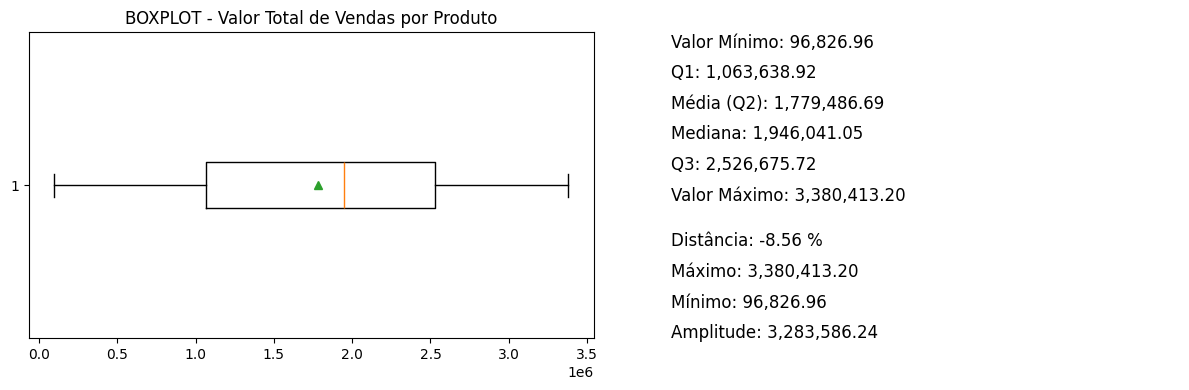

In [12]:
#Cria uma figura com 2 áreas de gráficos (1 linha x 2 colunas)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

#Gráfico 1: Linha - Vendas por dia da semana
axs[0].boxplot(arrayValorTotalProduto, vert=False, showmeans=True)
axs[0].set_title('BOXPLOT - Valor Total de Vendas por Produto')

#Gráfico 4: Quadro de texto explicativo
axs[1].axis('off')    #Desativa os eixos para poder incluir texto
axs[1].text(0.10, 0.95, f'Valor Mínimo: {minimo:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.85, f'Q1: {q1:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.75, f'Média (Q2): {media:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.65, f'Mediana: {mediana:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.55, f'Q3: {q3:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.45, f'Valor Máximo: {maximo:,.2f}', fontsize=12, color='black')

axs[1].text(0.10, 0.30, f'Distância: {distancia*100:,.2f} %', fontsize=12, color='black')
axs[1].text(0.10, 0.20, f'Máximo: {maximo:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.10, f'Mínimo: {minimo:,.2f}', fontsize=12, color='black')
axs[1].text(0.10, 0.00, f'Amplitude: {amplitude:,.2f}', fontsize=12, color='black')

#Ajusta os espaços entre os gráficos para evitar sobreposição
plt.tight_layout()

#Exibe todos os gráficos
plt.show()